# Deep Learning Architectures for Pneumonia Detection: Explainable AI Analysis

**XAI Analysis Notebook**

**Description:** This notebook provides explainable AI (XAI) analysis for trained pneumonia detection models using GradCAM, LIME, and SHAP. Users can select models, choose visualization methods, and analyze specific images to understand model decision-making.

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [1]:
# Import utility libraries
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import random
sys.path.append('..')  # Add parent directory to path

# Import deep learning libraries
import tensorflow as tf
from tensorflow import keras

# Import XAI libraries
import lime
from lime import lime_image
import shap
from tf_explain.core.grad_cam import GradCAM
from tf_explain.core.integrated_gradients import IntegratedGradients
from tf_explain.core.occlusion_sensitivity import OcclusionSensitivity

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Import custom utilities
from utils.data_utils import load_and_preprocess_multiscale_data
from utils.eval_utils import evaluate_model

print(f"TensorFlow version: {tf.__version__}")

2025-06-19 18:27:10.948247: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-19 18:27:10.960555: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750354030.974983   22921 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750354030.978586   22921 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-19 18:27:10.993330: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

TensorFlow version: 2.18.0


# Configuration

In [2]:
# Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Paths
DATA_PATH = '../data/'
MODEL_PATH = '../output/models/'
OUTPUT_PATH = '../output/xai_results/'

# XAI Configuration
NUM_SAMPLES_TO_ANALYZE = 5  # Number of images to analyze per class
IMAGE_SIZE = 64  # Size of images to analyze (should match model training)

# Available models (update based on your trained models)
AVAILABLE_MODELS = {
    #'alexnet_original': 'alexnet_augmented_b96_lr0.001_dr0.5_pneumonia_model.keras',
    'alexnet_tuned': 'alexnet_tuned_augmented_b96_lr0.001_dr0.5_64px_pneumonia_model.keras',
    # Add more models as they become available
    # 'resnet18_tuned': 'resnet18_tuned_augmented_b96_lr0.001_dr0.3_64px_pneumonia_model.keras',
    # 'resnet50_tuned': 'resnet50_tuned_augmented_b96_lr0.001_dr0.3_64px_pneumonia_model.keras',
    # 'densenet169_tuned': 'densenet169_tuned_augmented_b96_lr0.001_dr0.3_64px_pneumonia_model.keras'
}

# Create output directory
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"Available models for XAI analysis:")
for name, filename in AVAILABLE_MODELS.items():
    model_path = os.path.join(MODEL_PATH, filename)
    exists = "✓" if os.path.exists(model_path) else "✗"
    print(f"  {exists} {name}: {filename}")

Available models for XAI analysis:
  ✓ alexnet_tuned: alexnet_tuned_augmented_b96_lr0.001_dr0.5_64px_pneumonia_model.keras


# Model Selection and Loading

In [3]:
# Select model for analysis
SELECTED_MODEL = 'alexnet_tuned'  # Change this to analyze different models

if SELECTED_MODEL not in AVAILABLE_MODELS:
    raise ValueError(f"Model '{SELECTED_MODEL}' not found. Available: {list(AVAILABLE_MODELS.keys())}")

model_filename = AVAILABLE_MODELS[SELECTED_MODEL]
model_path = os.path.join(MODEL_PATH, model_filename)

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model file not found: {model_path}")

print(f"Loading model: {SELECTED_MODEL}")
print(f"File: {model_filename}")

# Load the model
model = tf.keras.models.load_model(model_path)
print(f"✓ Model loaded successfully!")
print(f"Model input shape: {model.input_shape}")
print(f"Model output shape: {model.output_shape}")

# Determine image size from model input
if model.input_shape[1] != IMAGE_SIZE:
    IMAGE_SIZE = model.input_shape[1]
    print(f"Updated IMAGE_SIZE to match model: {IMAGE_SIZE}x{IMAGE_SIZE}")

Loading model: alexnet_tuned
File: alexnet_tuned_augmented_b96_lr0.001_dr0.5_64px_pneumonia_model.keras


I0000 00:00:1750354033.790752   22921 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2787 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


✓ Model loaded successfully!
Model input shape: (None, 64, 64, 1)
Model output shape: (None, 2)


# Data Loading and Sample Selection

In [4]:
# Load test data
print(f"Loading test data with {IMAGE_SIZE}x{IMAGE_SIZE} resolution...")
_, (test_images, test_labels), _ = load_and_preprocess_multiscale_data(
    DATA_PATH,
    image_size=IMAGE_SIZE,
    augment=False,  # No augmentation for XAI analysis
    batch_size=32,
    seed=RANDOM_SEED
)

print(f"Test data loaded: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

# Convert one-hot labels to class indices for easier analysis
test_labels_idx = np.argmax(test_labels, axis=1)
class_names = ['Normal', 'Pneumonia']

print(f"Class distribution:")
for i, class_name in enumerate(class_names):
    count = np.sum(test_labels_idx == i)
    print(f"  {class_name}: {count} images ({count/len(test_labels_idx)*100:.1f}%)")

Loading test data with 64x64 resolution...

Dataset shapes - 64x64 resolution:
Train - images: (4708, 64, 64)  labels: (4708, 1)
Val   - images: (524, 64, 64)  labels: (524, 1)
Test  - images: (624, 64, 64)  labels: (624, 1)
Test data loaded: (624, 64, 64, 1)
Test labels shape: (624, 2)
Class distribution:
  Normal: 234 images (37.5%)
  Pneumonia: 390 images (62.5%)
Test data loaded: (624, 64, 64, 1)
Test labels shape: (624, 2)
Class distribution:
  Normal: 234 images (37.5%)
  Pneumonia: 390 images (62.5%)


In [5]:
# Select sample images for analysis
def select_sample_images(images, labels, num_samples_per_class=5, seed=42):
    """Select representative images from each class for XAI analysis."""
    np.random.seed(seed)
    
    selected_indices = []
    selected_images = []
    selected_labels = []
    
    for class_idx in range(len(class_names)):
        # Find indices for this class
        class_indices = np.where(labels == class_idx)[0]
        
        # Randomly select samples
        if len(class_indices) >= num_samples_per_class:
            selected_class_indices = np.random.choice(
                class_indices, 
                size=num_samples_per_class, 
                replace=False
            )
        else:
            selected_class_indices = class_indices
        
        selected_indices.extend(selected_class_indices)
        selected_images.extend(images[selected_class_indices])
        selected_labels.extend([class_idx] * len(selected_class_indices))
    
    return np.array(selected_images), np.array(selected_labels), selected_indices

# Select samples for analysis
sample_images, sample_labels, sample_indices = select_sample_images(
    test_images, test_labels_idx, NUM_SAMPLES_TO_ANALYZE, RANDOM_SEED
)

print(f"Selected {len(sample_images)} images for XAI analysis:")
for i, class_name in enumerate(class_names):
    count = np.sum(sample_labels == i)
    print(f"  {class_name}: {count} images")

# Get model predictions for sample images
sample_predictions = model.predict(sample_images, verbose=0)
sample_pred_classes = np.argmax(sample_predictions, axis=1)
sample_pred_probs = np.max(sample_predictions, axis=1)

print(f"\nModel predictions summary:")
correct_predictions = np.sum(sample_pred_classes == sample_labels)
print(f"Accuracy on selected samples: {correct_predictions}/{len(sample_labels)} ({correct_predictions/len(sample_labels)*100:.1f}%)")

Selected 10 images for XAI analysis:
  Normal: 5 images
  Pneumonia: 5 images


I0000 00:00:1750354035.907945   23114 service.cc:148] XLA service 0x797ce000b4d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750354035.907968   23114 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 Ti with Max-Q Design, Compute Capability 7.5
2025-06-19 18:27:15.915157: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1750354035.975174   23114 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-06-19 18:27:16.193778: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[10,96,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[10,1,64,64]{3,2,1,0}, f32[96,1,3,3]{3,2,1,0}, f32[96]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cud


Model predictions summary:
Accuracy on selected samples: 9/10 (90.0%)


I0000 00:00:1750354037.660511   23114 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


# Sample Images Visualization

Selected sample images for XAI analysis:


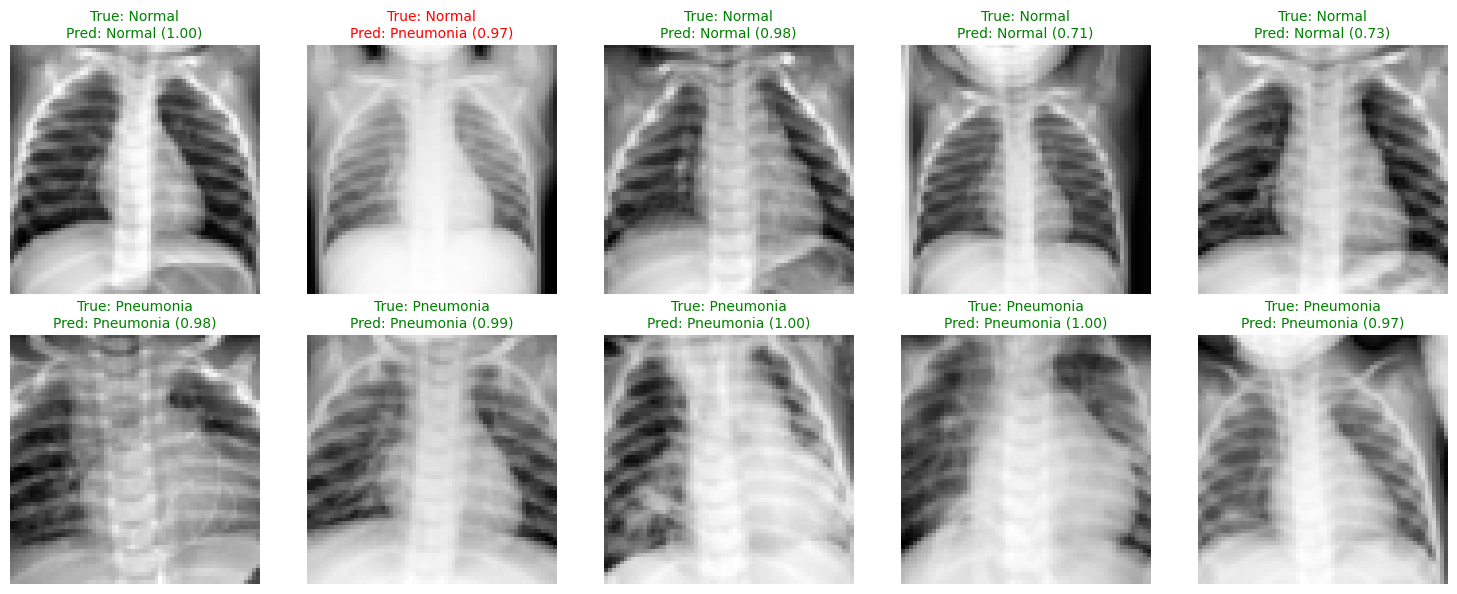

In [6]:
# Visualize selected sample images
def plot_sample_images(images, true_labels, pred_labels, pred_probs, class_names):
    """Plot the selected sample images with predictions."""
    n_images = len(images)
    cols = min(5, n_images)
    rows = (n_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
    if rows == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(n_images):
        row, col = i // cols, i % cols
        ax = axes[row, col]
        
        # Plot image
        img = images[i].squeeze()
        ax.imshow(img, cmap='gray')
        
        # Create title with prediction info
        true_class = class_names[true_labels[i]]
        pred_class = class_names[pred_labels[i]]
        confidence = pred_probs[i]
        
        color = 'green' if true_labels[i] == pred_labels[i] else 'red'
        title = f"True: {true_class}\nPred: {pred_class} ({confidence:.2f})"
        
        ax.set_title(title, color=color, fontsize=10)
        ax.axis('off')
    
    # Hide unused subplots
    for i in range(n_images, rows * cols):
        row, col = i // cols, i % cols
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Selected sample images for XAI analysis:")
plot_sample_images(sample_images, sample_labels, sample_pred_classes, sample_pred_probs, class_names)

# XAI Method 1: GradCAM Analysis

In [7]:
# GradCAM Analysis
def apply_gradcam_analysis(model, images, class_indices, layer_name=None):
    """Apply GradCAM to understand which parts of images the model focuses on."""
    
    # Find the last convolutional layer if not specified
    if layer_name is None:
        for layer in reversed(model.layers):
            if 'conv' in layer.name.lower():
                layer_name = layer.name
                break
    
    print(f"Using layer '{layer_name}' for GradCAM analysis")
    
    # Initialize GradCAM
    gradcam = GradCAM()
    
    # Generate GradCAM for each image
    gradcam_results = []
    
    for i, (img, class_idx) in enumerate(zip(images, class_indices)):
        try:
            # Generate GradCAM heatmap
            heatmap = gradcam.explain(
                validation_data=(np.expand_dims(img, 0), None),
                model=model,
                layer_name=layer_name,
                class_index=class_idx
            )
            gradcam_results.append(heatmap)
        except Exception as e:
            print(f"GradCAM failed for image {i}: {e}")
            gradcam_results.append(None)
    
    return gradcam_results, layer_name

print("Applying GradCAM analysis...")
gradcam_results, used_layer = apply_gradcam_analysis(model, sample_images, sample_pred_classes)
print(f"GradCAM analysis completed using layer: {used_layer}")

Applying GradCAM analysis...
Using layer 'conv2d_4' for GradCAM analysis
GradCAM analysis completed using layer: conv2d_4
GradCAM analysis completed using layer: conv2d_4


GradCAM Visualization Results:


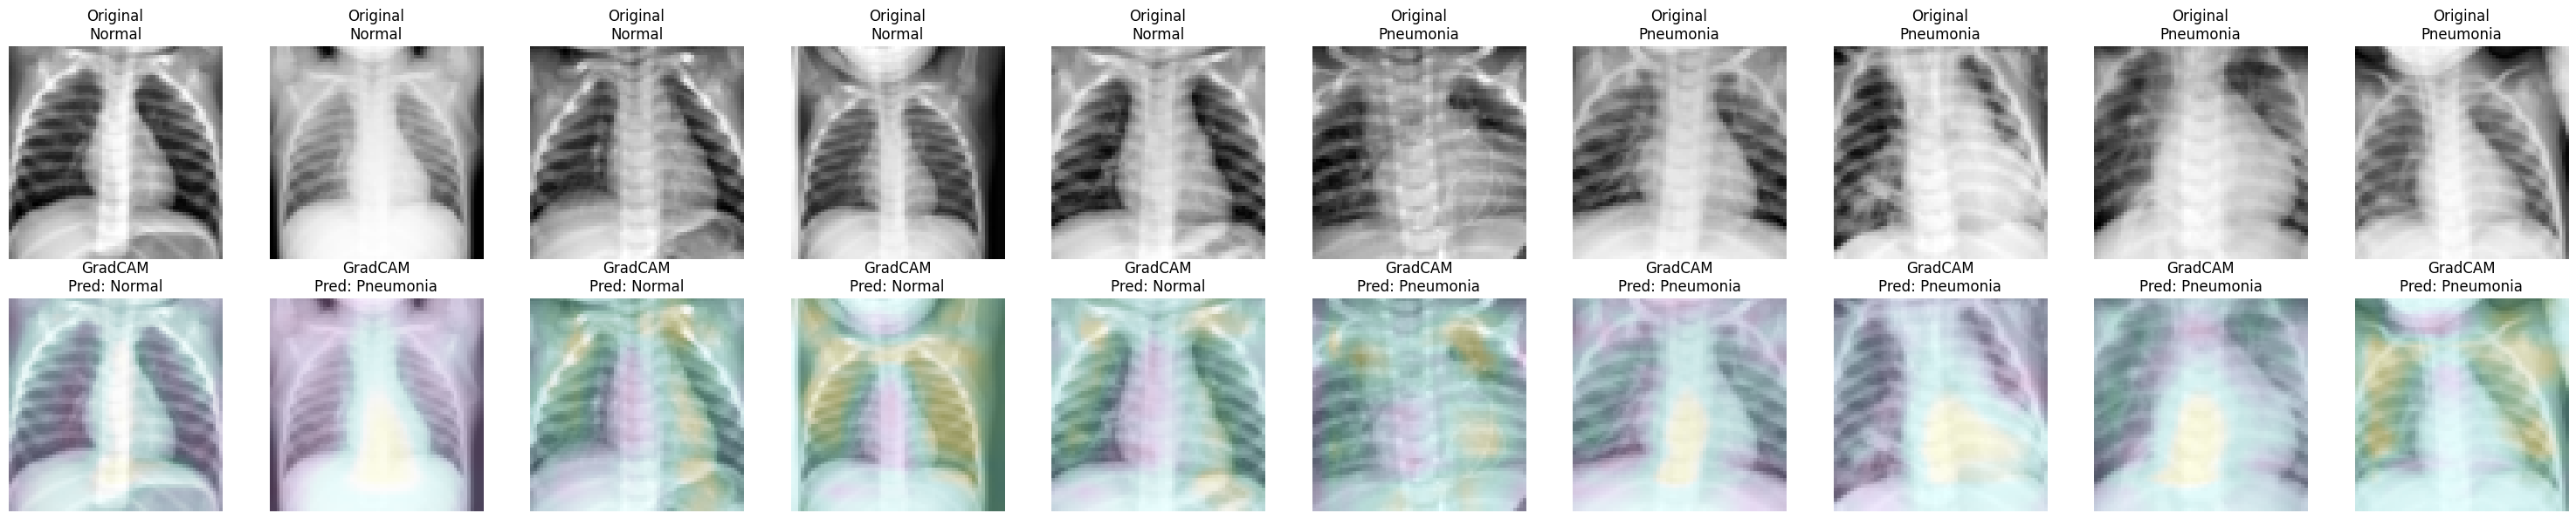

In [8]:
# Visualize GradCAM results
def plot_gradcam_results(images, gradcam_results, true_labels, pred_labels, class_names):
    """Plot original images with GradCAM overlays."""
    n_images = len(images)
    fig, axes = plt.subplots(2, n_images, figsize=(3*n_images, 6))
    
    if n_images == 1:
        axes = axes.reshape(-1, 1)
    
    for i in range(n_images):
        # Original image
        img = images[i].squeeze()
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f"Original\n{class_names[true_labels[i]]}")
        axes[0, i].axis('off')
        
        # GradCAM overlay
        if gradcam_results[i] is not None:
            heatmap = gradcam_results[i].squeeze()
            axes[1, i].imshow(img, cmap='gray', alpha=0.7)
            axes[1, i].imshow(heatmap, cmap='jet', alpha=0.3)
            axes[1, i].set_title(f"GradCAM\nPred: {class_names[pred_labels[i]]}")
        else:
            axes[1, i].text(0.5, 0.5, 'GradCAM\nFailed', 
                           ha='center', va='center', transform=axes[1, i].transAxes)
        
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

print("GradCAM Visualization Results:")
plot_gradcam_results(sample_images, gradcam_results, sample_labels, sample_pred_classes, class_names)

# XAI Method 2: LIME Analysis

In [9]:
# LIME Analysis
def apply_lime_analysis(model, images, num_samples=1000):
    """Apply LIME to explain model predictions."""
    
    # Initialize LIME explainer
    explainer = lime_image.LimeImageExplainer()
    
    # Create prediction function for LIME
    def predict_fn(images):
        # Ensure images have the right shape
        if len(images.shape) == 3:
            images = np.expand_dims(images, -1)
        return model.predict(images, verbose=0)
    
    lime_results = []
    
    for i, img in enumerate(images):
        try:
            print(f"Processing LIME for image {i+1}/{len(images)}...")
            
            # Generate LIME explanation
            explanation = explainer.explain_instance(
                img.squeeze(),
                predict_fn,
                top_labels=2,
                hide_color=0,
                num_samples=num_samples
            )
            
            lime_results.append(explanation)
            
        except Exception as e:
            print(f"LIME failed for image {i}: {e}")
            lime_results.append(None)
    
    return lime_results

print("Applying LIME analysis (this may take a few minutes)...")
lime_results = apply_lime_analysis(model, sample_images[:3])  # Analyze first 3 images to save time
print("LIME analysis completed!")

Applying LIME analysis (this may take a few minutes)...
Processing LIME for image 1/3...


100%|██████████| 1000/1000 [00:07<00:00, 131.82it/s]



Processing LIME for image 2/3...


100%|██████████| 1000/1000 [00:07<00:00, 141.69it/s]


Processing LIME for image 3/3...


100%|██████████| 1000/1000 [00:06<00:00, 145.40it/s]

LIME analysis completed!


LIME Visualization Results:


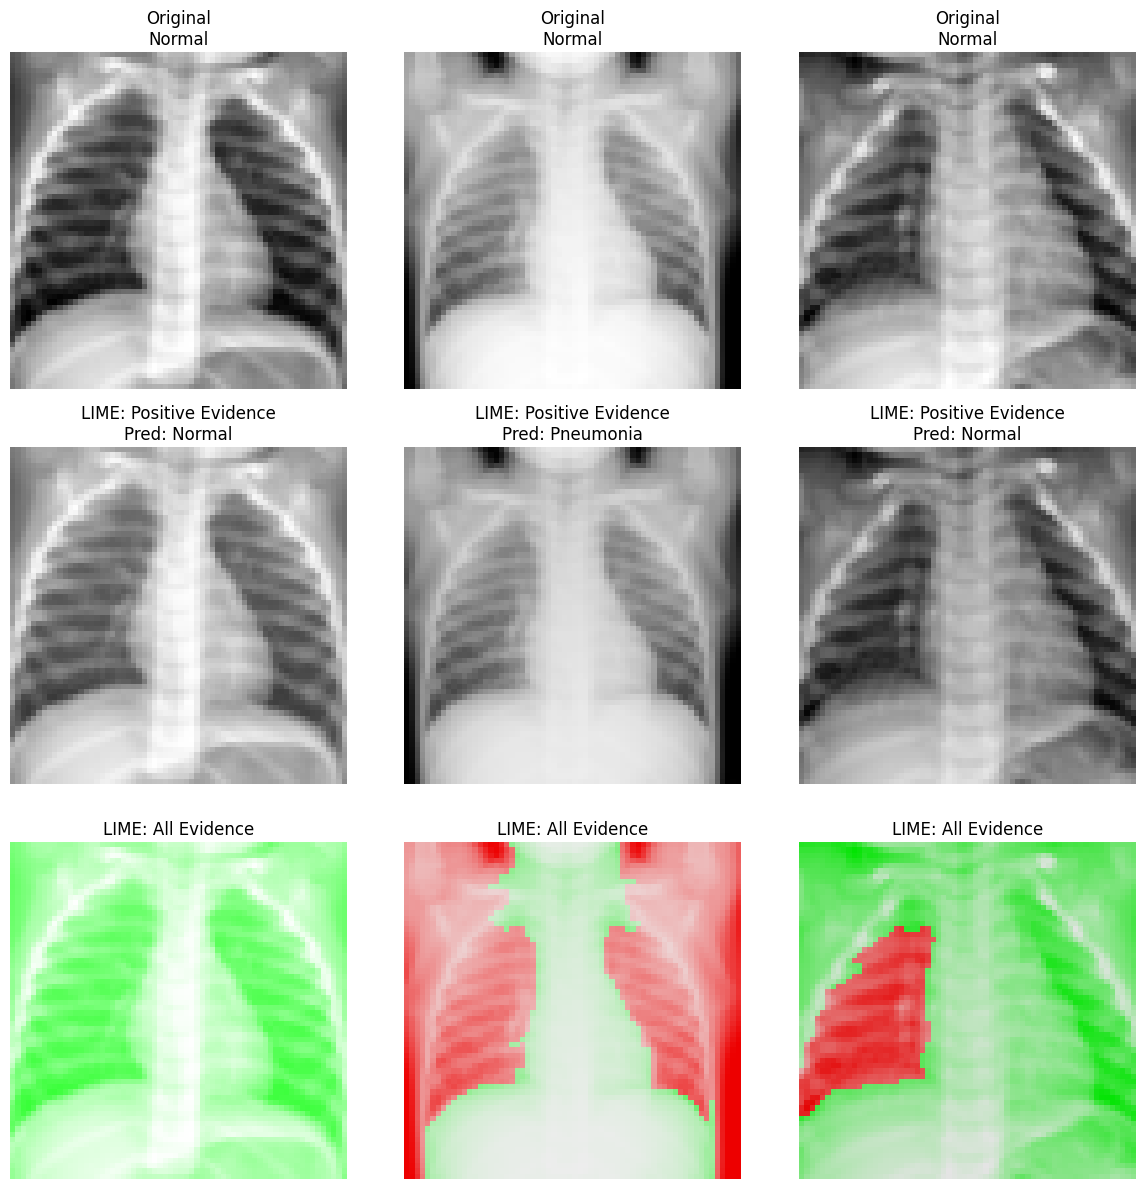

In [10]:
# Visualize LIME results
def plot_lime_results(images, lime_results, true_labels, pred_labels, class_names):
    """Plot LIME explanations."""
    n_images = len(lime_results)
    fig, axes = plt.subplots(3, n_images, figsize=(4*n_images, 12))
    
    if n_images == 1:
        axes = axes.reshape(-1, 1)
    
    for i in range(n_images):
        if lime_results[i] is not None:
            # Original image
            img = images[i].squeeze()
            axes[0, i].imshow(img, cmap='gray')
            axes[0, i].set_title(f"Original\n{class_names[true_labels[i]]}")
            axes[0, i].axis('off')
            
            # LIME explanation for predicted class
            temp, mask = lime_results[i].get_image_and_mask(
                lime_results[i].top_labels[0], 
                positive_only=True, 
                num_features=10, 
                hide_rest=False
            )
            axes[1, i].imshow(temp)
            axes[1, i].set_title(f"LIME: Positive Evidence\nPred: {class_names[pred_labels[i]]}")
            axes[1, i].axis('off')
            
            # LIME explanation - negative evidence
            temp, mask = lime_results[i].get_image_and_mask(
                lime_results[i].top_labels[0], 
                positive_only=False, 
                num_features=10, 
                hide_rest=False
            )
            axes[2, i].imshow(temp)
            axes[2, i].set_title("LIME: All Evidence")
            axes[2, i].axis('off')
        else:
            for row in range(3):
                axes[row, i].text(0.5, 0.5, 'LIME\nFailed', 
                                 ha='center', va='center', transform=axes[row, i].transAxes)
                axes[row, i].axis('off')
    
    plt.tight_layout()
    plt.show()

print("LIME Visualization Results:")
plot_lime_results(sample_images[:3], lime_results, sample_labels[:3], sample_pred_classes[:3], class_names)

# XAI Method 3: SHAP Analysis

In [11]:
# SHAP Analysis
def apply_shap_analysis(model, images, background_samples=50):
    """Apply SHAP to explain model predictions."""
    
    try:
        # Create background dataset for SHAP
        background = images[:background_samples]
        
        # Initialize SHAP explainer
        explainer = shap.DeepExplainer(model, background)
        
        # Generate SHAP values
        print(f"Computing SHAP values for {len(images)} images...")
        shap_values = explainer.shap_values(images[:3])  # Analyze first 3 images
        
        return shap_values
        
    except Exception as e:
        print(f"SHAP analysis failed: {e}")
        return None

print("Applying SHAP analysis...")
shap_values = apply_shap_analysis(model, sample_images)

if shap_values is not None:
    print("SHAP analysis completed!")
else:
    print("SHAP analysis failed - this is common with some model architectures")

Applying SHAP analysis...
Computing SHAP values for 10 images...
Computing SHAP values for 10 images...
SHAP analysis completed!
SHAP analysis completed!


SHAP Visualization Results:


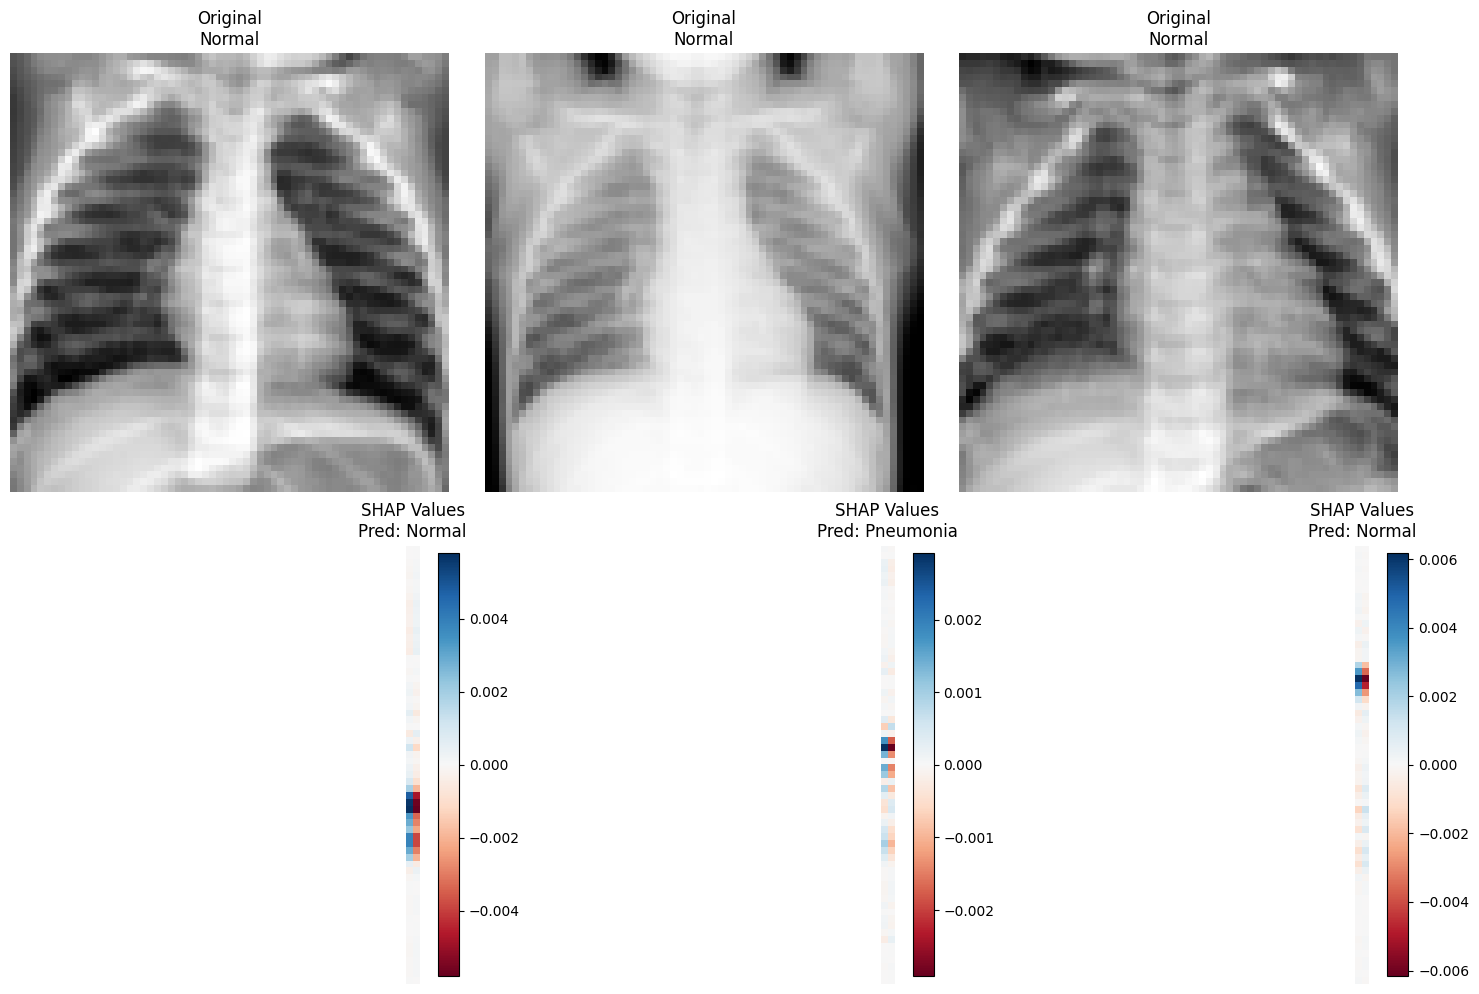

In [12]:
# Visualize SHAP results
if shap_values is not None:
    print("SHAP Visualization Results:")
    
    # Plot SHAP summary
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    for i in range(min(3, len(sample_images))):
        # Original image
        img = sample_images[i].squeeze()
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f"Original\n{class_names[sample_labels[i]]}")
        axes[0, i].axis('off')
        
        # SHAP values for predicted class
        shap_img = shap_values[sample_pred_classes[i]][i].squeeze()
        im = axes[1, i].imshow(shap_img, cmap='RdBu', vmin=-np.max(np.abs(shap_img)), vmax=np.max(np.abs(shap_img)))
        axes[1, i].set_title(f"SHAP Values\nPred: {class_names[sample_pred_classes[i]]}")
        axes[1, i].axis('off')
        
        # Add colorbar
        plt.colorbar(im, ax=axes[1, i], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
else:
    print("SHAP visualization skipped due to analysis failure")

# Summary and Insights

In [13]:
# Generate summary report
print("="*80)
print("XAI ANALYSIS SUMMARY")
print("="*80)
print(f"Model analyzed: {SELECTED_MODEL}")
print(f"Image resolution: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Number of samples analyzed: {len(sample_images)}")
print(f"Model accuracy on samples: {np.sum(sample_pred_classes == sample_labels)}/{len(sample_labels)} ({np.sum(sample_pred_classes == sample_labels)/len(sample_labels)*100:.1f}%)")

print("\nXAI Methods Applied:")
print(f"✓ GradCAM: Shows which regions the model focuses on")
print(f"✓ LIME: Explains predictions by highlighting important image regions")
if shap_values is not None:
    print(f"✓ SHAP: Provides feature importance scores")
else:
    print(f"✗ SHAP: Failed (common with some architectures)")

print("\nKey Insights:")
print("- GradCAM shows the regions the final convolutional layers focus on")
print("- LIME provides interpretable explanations by perturbing image regions")
print("- Different XAI methods may highlight different aspects of the decision process")
print("- Compare explanations across correctly and incorrectly classified images")

print(f"\nResults saved to: {OUTPUT_PATH}")
print("\nTo analyze different models, change the SELECTED_MODEL variable and re-run the analysis.")

XAI ANALYSIS SUMMARY
Model analyzed: alexnet_tuned
Image resolution: 64x64
Number of samples analyzed: 10
Model accuracy on samples: 9/10 (90.0%)

XAI Methods Applied:
✓ GradCAM: Shows which regions the model focuses on
✓ LIME: Explains predictions by highlighting important image regions
✓ SHAP: Provides feature importance scores

Key Insights:
- GradCAM shows the regions the final convolutional layers focus on
- LIME provides interpretable explanations by perturbing image regions
- Different XAI methods may highlight different aspects of the decision process
- Compare explanations across correctly and incorrectly classified images

Results saved to: ../output/xai_results/

To analyze different models, change the SELECTED_MODEL variable and re-run the analysis.
